<a href="https://colab.research.google.com/github/Hanamokhles05/k-means/blob/main/02_Credit_Card_Customer_Segmentation_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ARTI308 - Machine Learning

# Credit Card Customer Segmentation Project

In this project, you will use K-Means clustering to segment [credit card customers](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata/data) based on their usage behavior. This is an unsupervised learning problem because the dataset does not contain a target label for customer groups.

You will use the `CC_GENERAL.csv` dataset.

## About the Dataset

The dataset contains customer-level credit card usage behavior. Each row represents one credit card holder, and the columns describe different behavioral variables such as balance, purchases, cash advance, payments, and tenure. The goal is to group similar customers together so that the company can understand different customer segments and design better marketing strategies.

## Import Libraries

**Import the libraries you need for data analysis, visualization, preprocessing, clustering, and evaluation.**

In [18]:
 import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Get the Data

**Read the `CC_GENERAL.csv` file and save it in a dataframe called `df`.**

In [2]:
 df = pd.read_csv('CC_GENERAL.csv')

**Check the first five rows of the dataset.**

In [3]:
 print(df.head())

  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000       

**Check the shape of the dataset.**

In [4]:
 print(df.shape)

(8950, 18)


**Check basic information about the dataset using `info()`.**

In [5]:
 print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

**Check summary statistics using `describe()`.**

In [6]:
 print(df.describe())

            BALANCE  BALANCE_FREQUENCY     PURCHASES  ONEOFF_PURCHASES  \
count   8950.000000        8950.000000   8950.000000       8950.000000   
mean    1564.474828           0.877271   1003.204834        592.437371   
std     2081.531879           0.236904   2136.634782       1659.887917   
min        0.000000           0.000000      0.000000          0.000000   
25%      128.281915           0.888889     39.635000          0.000000   
50%      873.385231           1.000000    361.280000         38.000000   
75%     2054.140036           1.000000   1110.130000        577.405000   
max    19043.138560           1.000000  49039.570000      40761.250000   

       INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
count             8950.000000   8950.000000          8950.000000   
mean               411.067645    978.871112             0.490351   
std                904.338115   2097.163877             0.401371   
min                  0.000000      0.000000             0.000

## Data Cleaning

The column `CUST_ID` is an identification column. It is not useful for clustering because it does not describe customer behavior.

**Drop the `CUST_ID` column from the dataframe.**

In [22]:
 drop= df.drop('CUST_ID',axis =1)

**Check the missing values in each column.**

In [8]:
 print(df.head())

  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000       

Some columns may contain missing values.

Hint: You can handle missing values by either:
- filling them with the mean value
- or dropping the rows that contain missing values

For this project, use mean imputation.

**Fill the missing values with the mean of each column.**

In [13]:
# Fill missing values with mean values
df = df.fillna(df.mean(numeric_only=True))

**Check the missing values again to make sure they were handled.**

In [14]:

# Check missing values
print(df.isnull().sum())

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


## Exploratory Data Analysis

Before applying clustering, it is important to understand the data.

**Create histograms for the numerical columns.**

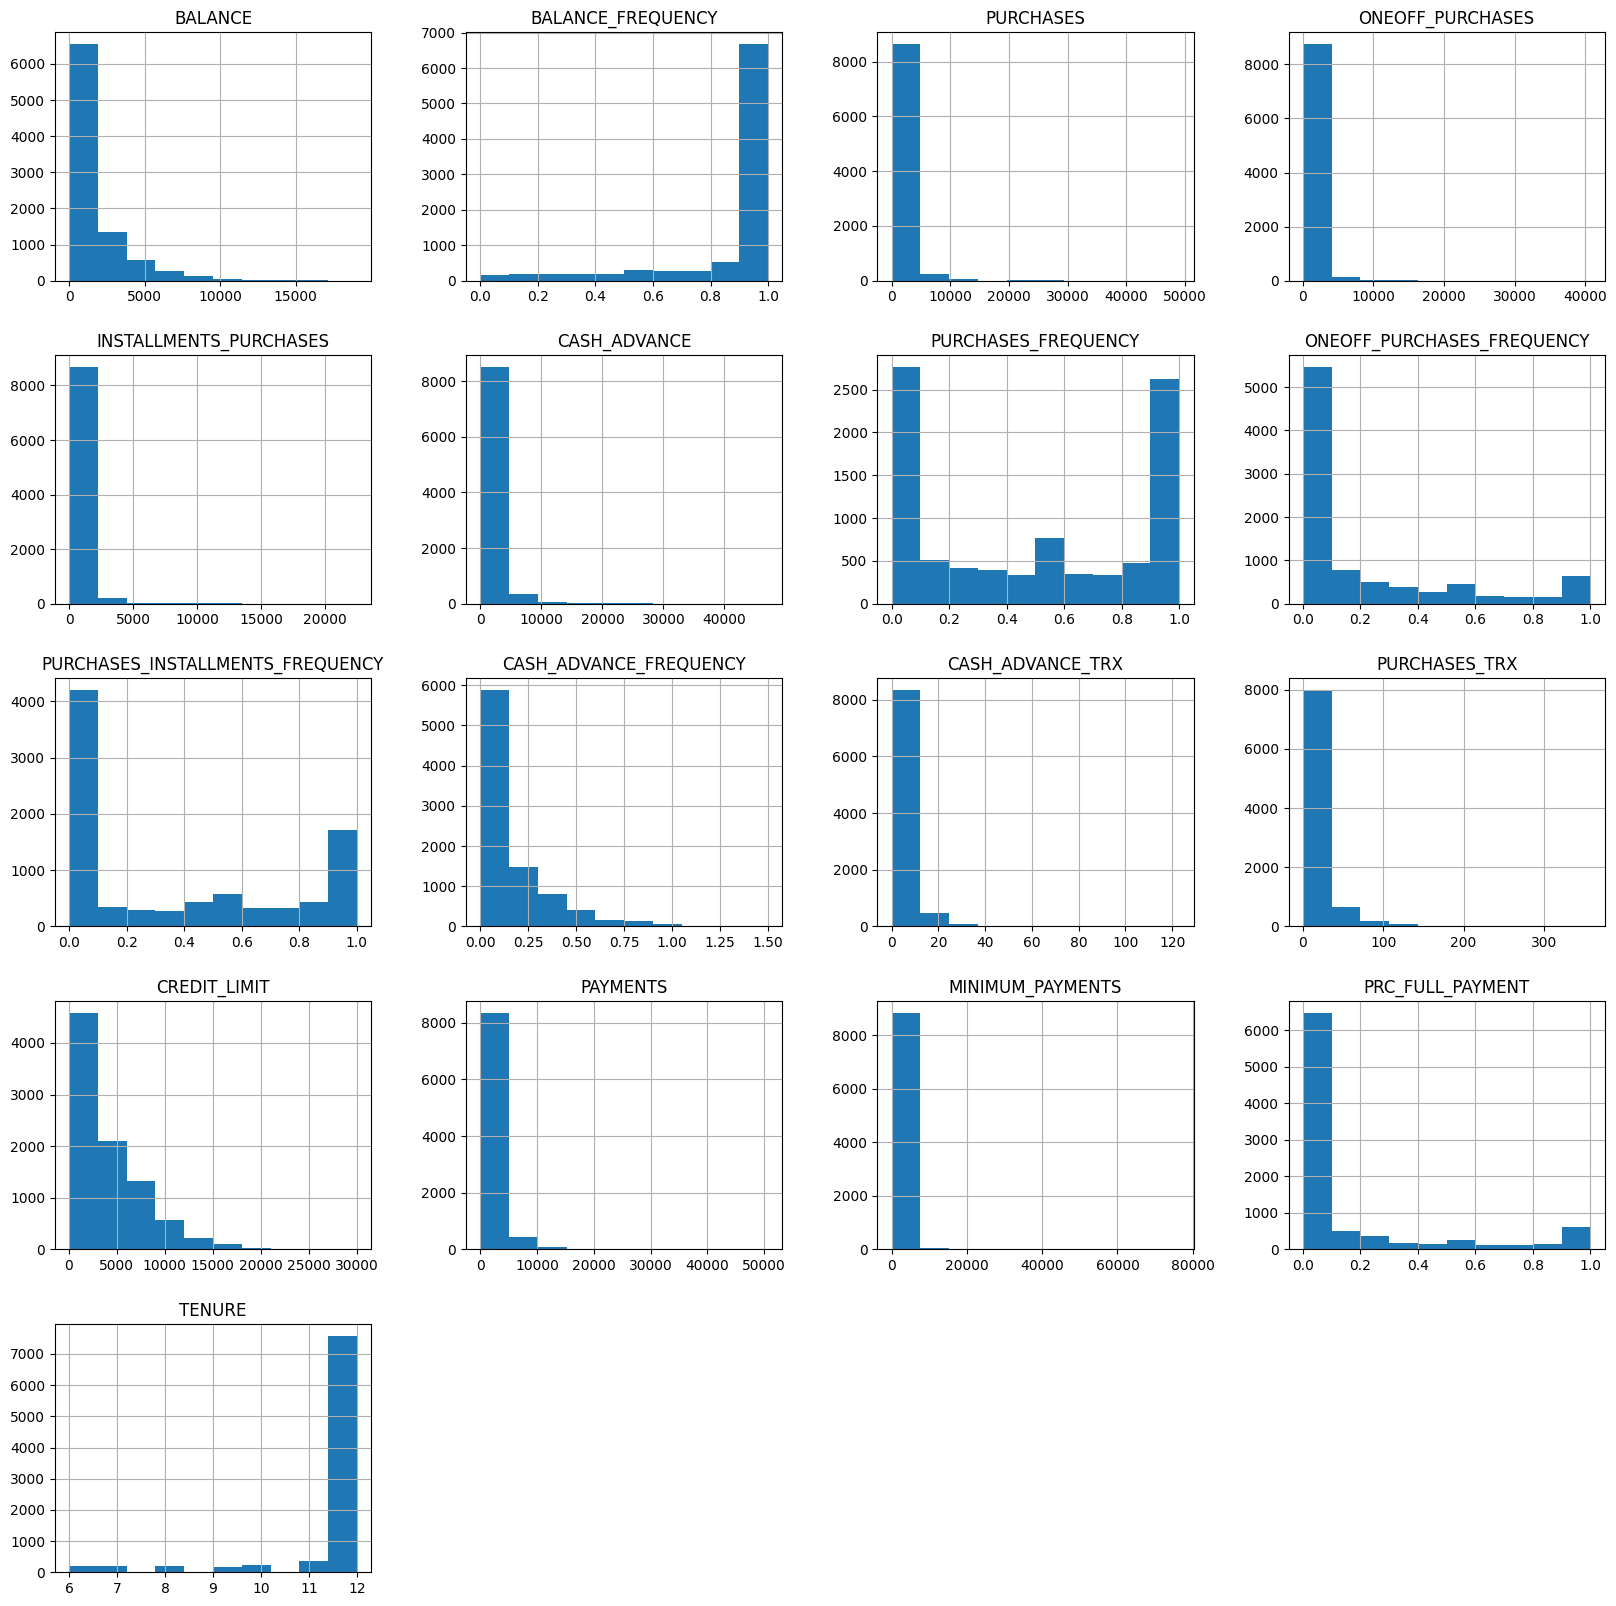

In [15]:
 df.hist(figsize=(20, 20))
plt.show()

**Create a correlation heatmap to understand relationships between the features.**

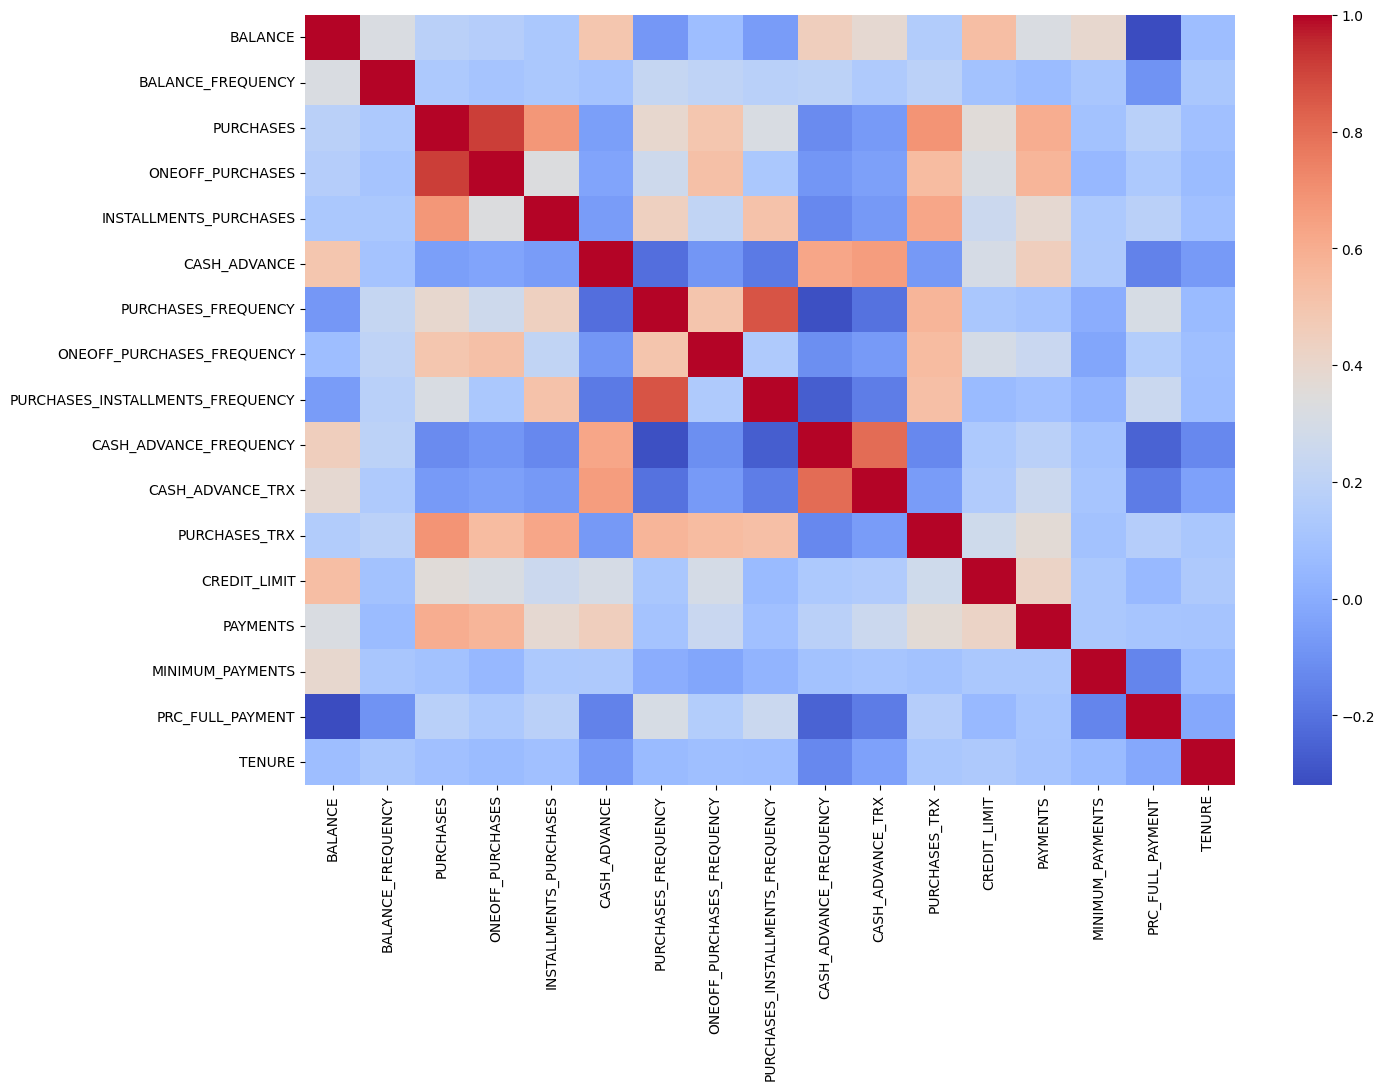

In [25]:

# Create correlation heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.show()

**Create a scatter plot between `BALANCE` and `PURCHASES`.**

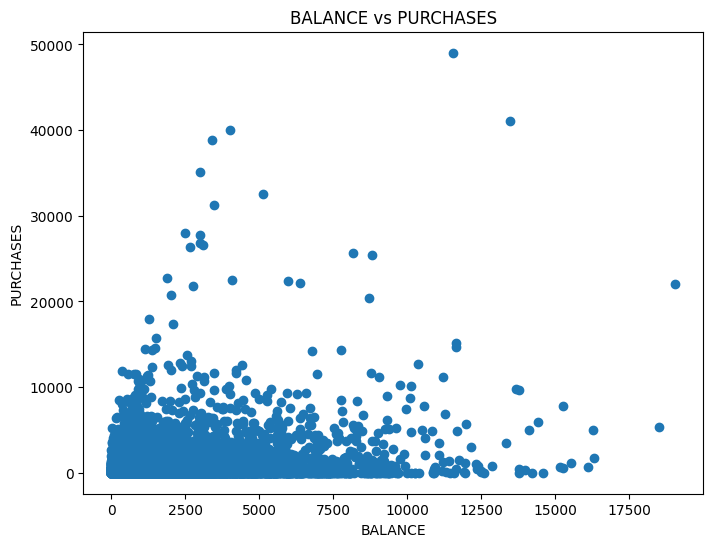

In [26]:
 plt.figure(figsize=(8,6))
plt.scatter(df['BALANCE'], df['PURCHASES'])
plt.xlabel('BALANCE')
plt.ylabel('PURCHASES')
plt.title('BALANCE vs PURCHASES')
plt.show()

**Create a scatter plot between `BALANCE` and `CASH_ADVANCE`.**

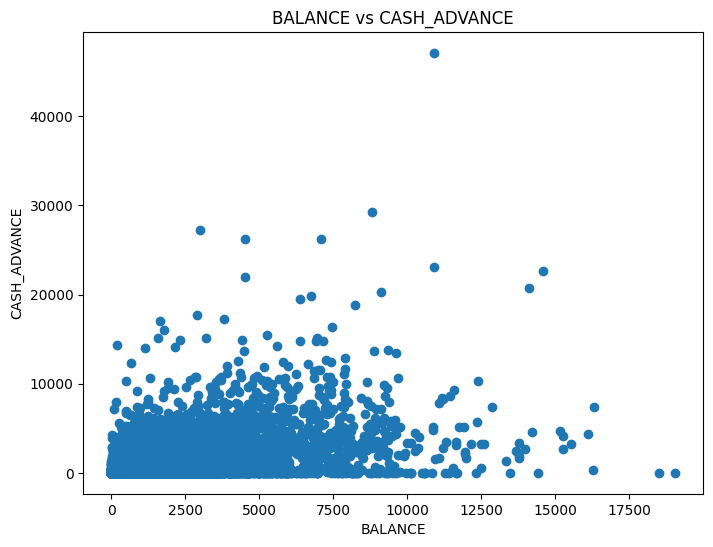

In [27]:

plt.figure(figsize=(8,6))
plt.scatter(df['BALANCE'], df['CASH_ADVANCE'])
plt.xlabel('BALANCE')
plt.ylabel('CASH_ADVANCE')
plt.title('BALANCE vs CASH_ADVANCE')
plt.show()

## Feature Scaling

K-Means is a distance-based algorithm. Therefore, feature scaling is very important.

The features in this dataset have very different ranges. For example, `BALANCE`, `PURCHASES`, and `CREDIT_LIMIT` may have large values, while frequency columns are between 0 and 1.

**Use StandardScaler to scale the data. Save the scaled data in a variable called `X_scaled`.**

In [29]:
from sklearn.preprocessing import StandardScaler

# Make sure we only keep numeric columns
df_numeric = df.select_dtypes(include=['number'])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

print(X_scaled.shape)

(8950, 17)


## Choosing K Intuitively

Choosing K is one of the most difficult parts of K-Means.

Since this dataset has many features, it is not easy to visually see the clusters directly.

However, we can still compare different K values using the elbow method and silhouette score.

## Elbow Method

**Create a loop that fits K-Means models for K values from 1 to 10. Save the inertia values in a list called `inertia_values`.**

In [30]:
 from sklearn.cluster import KMeans

inertia_values = []

# Try K from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

print(inertia_values)

[152149.99999999875, 127785.00756531829, 111986.6980661014, 99073.93826774786, 91502.98259428954, 84852.5245386828, 79532.32854113283, 76050.70276210467, 71087.2678752301, 66612.6924406699]


**Plot the elbow curve.**

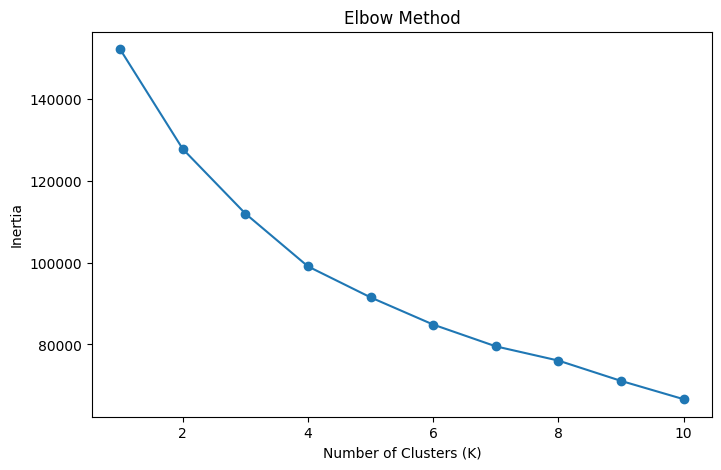

In [32]:
 import matplotlib.pyplot as plt

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia_values, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

**Output Interpretation**

Look at the elbow curve and try to identify where the decrease in inertia starts to slow down.

That point can suggest a reasonable value for K.

## Silhouette Score

The silhouette score helps evaluate how well-separated the clusters are.

**Create a loop that calculates the silhouette score for K values from 2 to 10. Save the scores in a list called `silhouette_scores`.**

In [34]:
 silhouette_scores = []

# K from 2 to 10
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

print(silhouette_scores)

[np.float64(0.21003302619400505), np.float64(0.25055570796307736), np.float64(0.1976074492720698), np.float64(0.1931688590154638), np.float64(0.20263931739848778), np.float64(0.21503808606365246), np.float64(0.20809196271641647), np.float64(0.2149116403835865), np.float64(0.2205181120683996)]


**Plot the silhouette scores.**

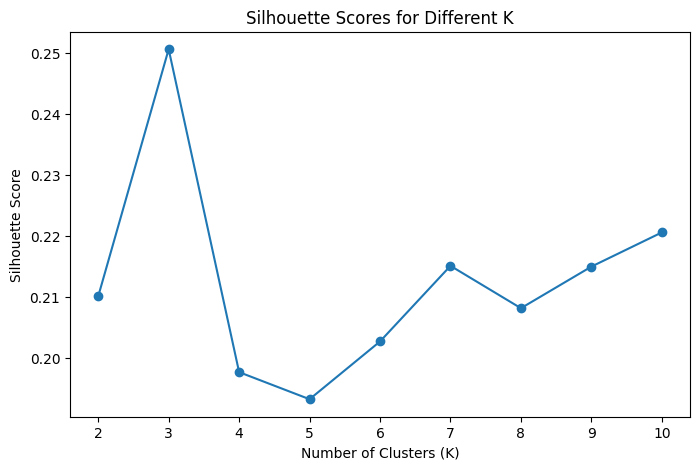

In [36]:
 plt.figure(figsize=(8,5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different K')
plt.show()

**Create a table showing each K value and its silhouette score.**

In [38]:
 import pandas as pd
results_df = pd.DataFrame({
    "K": range(2, 11),
    "Silhouette Score": silhouette_scores
})

print(results_df)

    K  Silhouette Score
0   2          0.210033
1   3          0.250556
2   4          0.197607
3   5          0.193169
4   6          0.202639
5   7          0.215038
6   8          0.208092
7   9          0.214912
8  10          0.220518


**Output Interpretation**

A higher silhouette score usually means better clustering.

However, do not rely only on the highest value. Also consider whether the chosen K makes sense for customer segmentation.

## Create the Final K-Means Model

**Based on the elbow curve and silhouette scores, choose a final K value. Then train a final K-Means model.**

Use `random_state=42` and `n_init=10`.

In [41]:

k = 4
kmeans_final = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

**Add the final cluster labels to the original dataframe in a new column called `Cluster`.**

In [42]:
 df['Cluster'] = clusters

print(df.head())

  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000       

**Check the first five rows after adding the cluster labels.**

In [43]:
 print(df.head())

  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000       

## Cluster Analysis

Now we need to understand what each cluster means.

**Create a summary table using `groupby()` to show the mean values of each feature for each cluster.**

In [47]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

print(cluster_summary)

             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                  
0         894.907458           0.934734  1236.178934        593.974874   
1        3551.153761           0.986879  7681.620098       5095.878826   
2        4602.462714           0.968415   501.896219        320.373681   
3        1011.751528           0.789871   269.973466        209.853863   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                    642.478274    210.570626             0.885165   
1                   2587.208264    653.638891             0.946418   
2                    181.607404   4520.724309             0.287731   
3                     60.386625    595.759339             0.170146   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                                                      

## :**Check how many customers are in each cluster.**

In [48]:
 cluster_counts = df['Cluster'].value_counts()

print(cluster_counts)

Cluster
3    3976
0    3367
2    1198
1     409
Name: count, dtype: int64


## Visualizing the Final Clusters

Since the dataset has many features, we will use PCA to reduce the data into two components only for visualization.

This visualization does not replace the original clustering. It only helps us see the clusters in a 2D plot.

**Use PCA with 2 components and plot the clusters.**

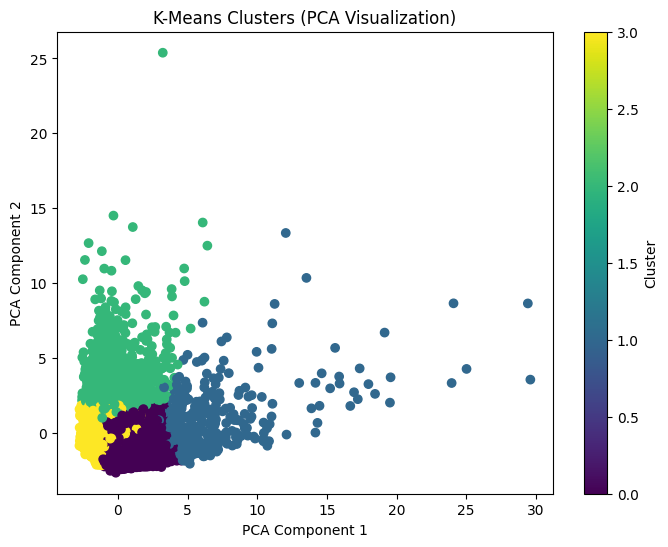

In [49]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clusters (PCA Visualization)')
plt.colorbar(label='Cluster')
plt.show()

**Output Interpretation**

The PCA plot gives a simplified 2D view of the clusters.

If the clusters are not perfectly separated, that is normal because the original dataset has many features and the plot only shows two compressed dimensions.

## Final Questions

Answer the following questions:

1. Why is this an unsupervised learning problem?

2. Why did we remove the `CUST_ID` column?

3. Which columns had missing values?

4. How did you handle the missing values?

5. Why is scaling important before applying K-Means?

6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.

7. Based on the cluster summary table, describe each customer segment in your own words.

8. Which cluster may represent high-value customers?

9. Which cluster may represent customers who rely more on cash advance?

10. How can a company use these clusters for marketing strategy?

1. Why is this an unsupervised learning problem?

Because we don’t have labeled outputs (no target column). The goal is to discover hidden patterns or groups in the data using clustering (K-Means), not to predict a known label.

2. Why did we remove the CUST_ID column?

Because CUST_ID is just an identifier. It does not contain behavioral information about customers, so it would not help clustering and could distort the distance calculations.

3. Which columns had missing values?

Typically in this dataset, missing values appear in features like:

MINIMUM_PAYMENTS
CREDIT_LIMIT

(You can confirm this using df.isnull().sum().)

4. How did you handle the missing values?

We used mean imputation, meaning each missing value was replaced with the average value of that column:
df = df.fillna(df.mean(numeric_only=True))



5. Why is scaling important before applying K-Means?

K-Means is distance-based, so features with larger ranges (like BALANCE or PURCHASES) would dominate the clustering. Scaling ensures all features contribute equally by putting them on the same scale.

We used StandardScaler to normalize the data.

6. Which K value did you choose? Explain using elbow + silhouette score.

You choose K where:

The elbow curve starts to flatten (inertia stops decreasing significantly)
The silhouette score is relatively high compared to other K values

 In most cases for this dataset, a good choice is often K = 4 or K = 5, depending on your plots.

7. Describe each customer segment (cluster summary)

Based on typical credit card segmentation:

Cluster 0: Low activity customers (low balance, low purchases)
Cluster 1: Regular spenders (moderate purchases and balance)
Cluster 2: High spenders (high purchases, high credit usage)
Cluster 3: Cash advance users (high cash advance usage, possibly low purchases)
8. Which cluster may represent high-value customers?

The cluster with:

High PURCHASES
High CREDIT_LIMIT
High BALANCE but controlled usage

 Usually this is the high-spending cluster (often Cluster 2).

9. Which cluster may represent customers who rely more on cash advance?

The cluster with:

High CASH_ADVANCE
Possibly lower purchases

 Typically the cash-advance-heavy cluster (often Cluster 3).

10. How can a company use these clusters for marketing strategy?

Companies can:

Offer premium rewards to high-value customers
Send discount offers to low-activity users to increase engagement
Provide financial management tools to cash-advance users
Create personalized marketing campaigns for each segment